In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from thyrosim_model import Thyrosim, run_simulation, compute_ft4_ft3

In [2]:
# Create parameters
def create_default_params():
    params = {}
    for i in range(1,49):
        params[f"p{i}"] = 1.0
    return params

In [12]:
# Simulate
def simulate_rtf(rtf):

    params = create_default_params()

    # Assume RTF corresponds to parameter p1
    params["p1"] = rtf

    dial = [1,1,1,1]
    inf = [0,0]

    model = Thyrosim(
        dial=dial,
        inf=inf,
        kdelay=0.1,
        params=params
    )

    initial_conditions = np.ones(19)

    t, states = run_simulation(model, 0, 10000, initial_conditions)

    ft4, ft3 = compute_ft4_ft3(states, params)

    tsh = states[6]

    # return steady state averages
    return np.mean(ft4[-20:]), np.mean(ft3[-20:]), np.mean(tsh[-20:])

In [4]:
# Create "fake" dataset
def generate_dataset():

    rtf_values = np.linspace(0.1,1.0,20)

    data = []

    for rtf in rtf_values:

        ft4, ft3, tsh = simulate_rtf(rtf)

        data.append([rtf, ft4, ft3, tsh])

    df = pd.DataFrame(data, columns=["RTF","FT4","FT3","TSH"])

    return df

In [5]:
# grid search
def estimate_rtf(observed_ft4, observed_ft3, observed_tsh, dataset):

    errors = []

    for _, row in dataset.iterrows():

        err = (
            (row.FT4 - observed_ft4)**2 +
            (row.FT3 - observed_ft3)**2 +
            (row.TSH - observed_tsh)**2
        )

        errors.append(err)

    best_index = np.argmin(errors)

    return dataset.iloc[best_index]["RTF"]

In [14]:
# Plotting stuff

def plot_time_series():

    params = create_default_params()
    params["p1"] = 0.8

    dial = [1,1,1,1]
    inf = [0,0]

    model = Thyrosim(dial, inf, 0.1, params)

    initial_conditions = np.ones(19)

    t, states = run_simulation(model, 0, 1000, initial_conditions)

    ft4, ft3 = compute_ft4_ft3(states, params)

    tsh = states[6]

    plt.figure()
    plt.plot(t, ft4, label="FT4")
    plt.plot(t, ft3, label="FT3")
    plt.plot(t, tsh, label="TSH")

    plt.xlabel("Time")
    plt.ylabel("Hormone Level")
    plt.title("Hormone Time Series")
    plt.legend()

    plt.show()

def plot_rtf_vs_hormones():

    rtf_vals = np.linspace(0.1,1.0,25)

    ft4_list = []
    ft3_list = []
    tsh_list = []

    for rtf in rtf_vals:

        ft4, ft3, tsh = simulate_rtf(rtf)

        ft4_list.append(ft4)
        ft3_list.append(ft3)
        tsh_list.append(tsh)

    plt.figure()
    plt.plot(rtf_vals, ft4_list, label="FT4")
    plt.plot(rtf_vals, ft3_list, label="FT3")
    plt.plot(rtf_vals, tsh_list, label="TSH")

    plt.xlabel("RTF")
    plt.ylabel("Steady State Hormone Level")
    plt.title("Effect of RTF on Hormone Levels")

    plt.legend()
    plt.show()

def plot_multiple_rtf():

    rtf_values = [0.2, 0.5, 0.8]

    plt.figure()

    for rtf in rtf_values:

        params = create_default_params()
        params["p1"] = rtf

        model = Thyrosim([1,1,1,1],[0,0],0.1,params)

        t, states = run_simulation(model,0,1000,np.ones(19))

        ft4, _ = compute_ft4_ft3(states, params)

        plt.plot(t, ft4, label=f"RTF={rtf}")

    plt.xlabel("Time")
    plt.ylabel("FT4")
    plt.title("FT4 Dynamics for Different RTF Values")
    plt.legend()

    plt.show()

def plot_estimation_error():

    dataset = generate_dataset()

    true_vals = np.linspace(0.1,1.0,20)

    errors = []

    for true_rtf in true_vals:

        ft4, ft3, tsh = simulate_rtf(true_rtf)

        est = estimate_rtf(ft4, ft3, tsh, dataset)

        errors.append(abs(est - true_rtf))

    plt.figure()

    plt.plot(true_vals, errors)

    plt.xlabel("True RTF")
    plt.ylabel("Absolute Estimation Error")
    plt.title("RTF Estimation Error")

    plt.show()

def plot_true_vs_estimated():

    dataset = generate_dataset()

    true_vals = np.linspace(0.01,1.0,20)
    estimated_vals = []

    for true_rtf in true_vals:

        ft4, ft3, tsh = simulate_rtf(true_rtf)

        est = estimate_rtf(ft4, ft3, tsh, dataset)

        estimated_vals.append(est)

    plt.figure()

    plt.scatter(true_vals, estimated_vals)

    # perfect estimator reference
    plt.plot(true_vals, true_vals, color="red")

    plt.xlabel("True RTF")
    plt.ylabel("Estimated RTF")

    plt.title("True vs Estimated RTF")
    plt.show()

In [ ]:
dataset = generate_dataset()

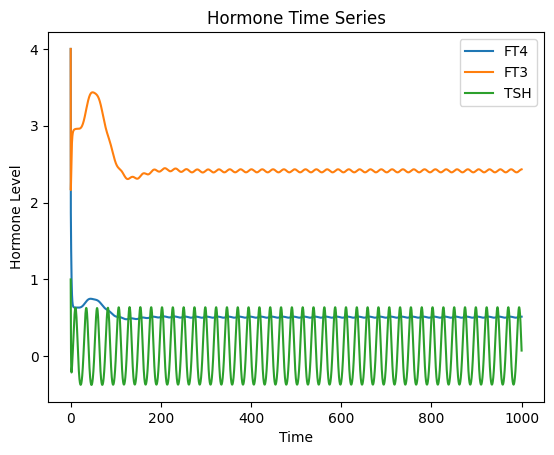

In [7]:
plot_time_series()

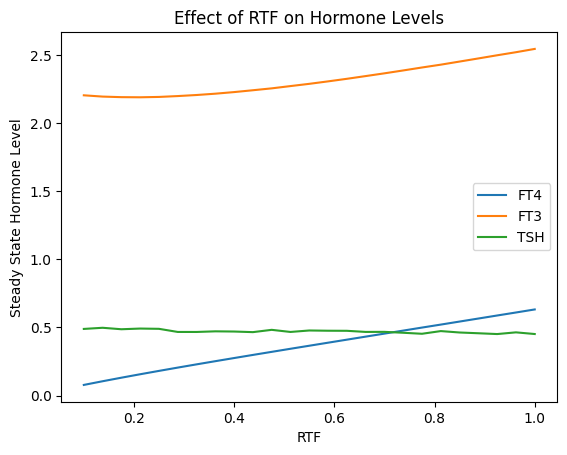

In [8]:
plot_rtf_vs_hormones()

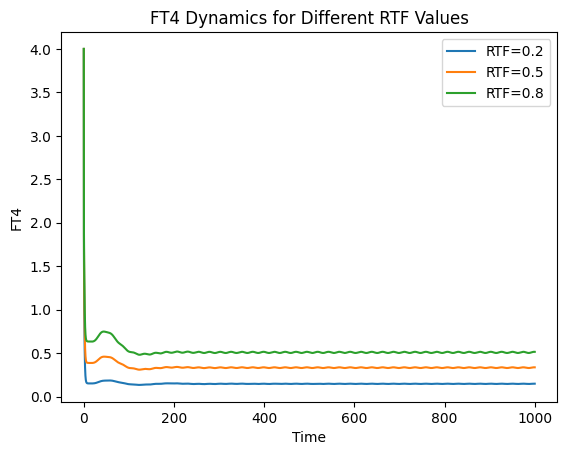

In [9]:
plot_multiple_rtf()

In [17]:
# pretend we don't actually know this
true_rtf = 0.38965

ft4, ft3, tsh = simulate_rtf(true_rtf)

estimated_rtf = estimate_rtf(ft4, ft3, tsh, dataset)

print("\nTrue RTF:", true_rtf)
print("Estimated RTF:", estimated_rtf)


True RTF: 0.38965
Estimated RTF: 0.38421052631578945


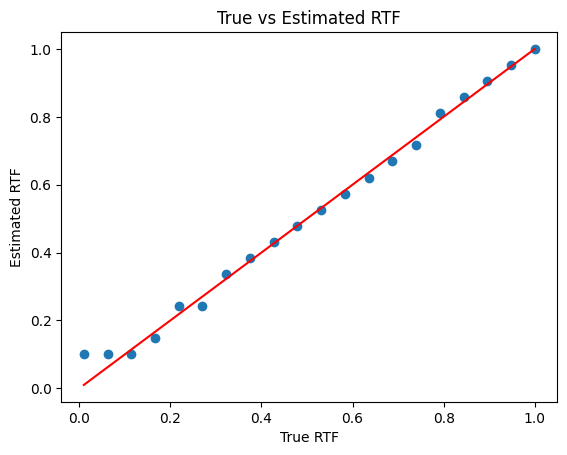

In [15]:
plot_true_vs_estimated()